In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq

Matplotlib is building the font cache; this may take a moment.


In [25]:
ticker = 'AAPL'
data = yf.download(ticker, start="2023""-01-01", end="2026-01-01", auto_adjust=True) # Precio de cierre ajustado
df = pd.DataFrame(data)

# Colapso de Covid-19 cambia drásticamente la varianza, estudiar desde 2023.

[*********************100%***********************]  1 of 1 completed


In [26]:
# Retornos y Volatilidad
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Returns'].rolling(window=21).std() # Volatilidad móvil de 21 días
df.dropna(inplace=True)
print(df)

Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2023-02-02  148.302979  148.656956  145.697195  146.415008  118339000   
2023-02-03  151.921570  154.753511  145.362886  145.559546  154357300   
2023-02-06  149.197784  150.544931  148.263642  150.023777   69858300   
2023-02-07  152.069046  152.639368  148.125974  148.125974   83322600   
2023-02-08  149.384598  152.000209  148.647115  151.311894   64120100   
...                ...         ...         ...         ...        ...   
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600   
2025-12-26  272.893005  274.859353  272.353998  273.651606   21521800   
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200   
2025-12-30  272.573547  273.571693  271.775043  272.304059   22139600   
2025-12-31  271.355835  273.172467  271.246054  272

In [27]:
# Test ADF
print(f'Test ADF para Precios de cierre de ({ticker})')
p_value = adfuller(df['Close']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}')

print(f'Test ADF para Retornos logarítmicos de ({ticker})')
p_value = adfuller(df['Returns']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}') 

Test ADF para Precios de cierre de (AAPL)
P-value: 0.6952
Test ADF para Retornos logarítmicos de (AAPL)
P-value: 0.0000


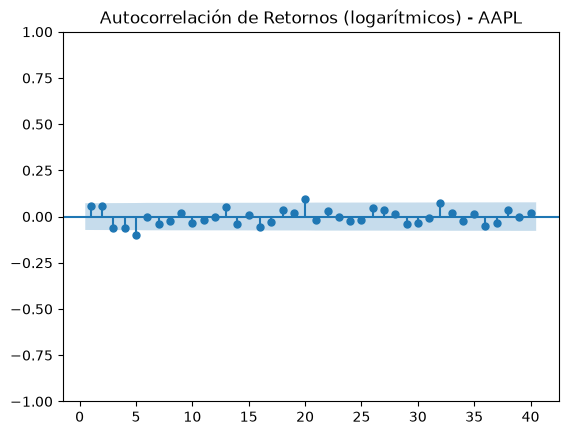

In [29]:
# Autocorrelación
plot_acf(df['Returns'], lags=40, zero=False)
plt.title(f"Autocorrelación de Retornos (logarítmicos) - {ticker}")
plt.show()

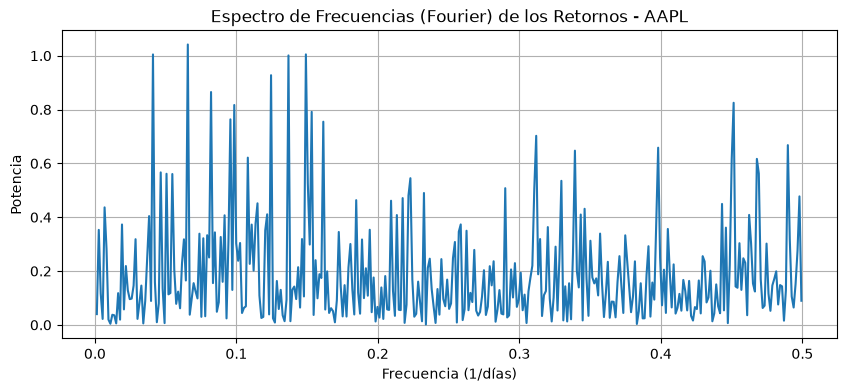

In [32]:
# Fourier (Expectro de Potencia)
# FFT sobre retornos para buscar periodicidades
N = len(df['Returns'])
returns_array = df['Returns'].values

yf_fft = fft(returns_array)
xf_freq = fftfreq(N, d=1) # 1 día de muestreo

pos_freq = xf_freq > 0 # 
frequencies = xf_freq[pos_freq]
power = np.abs(yf_fft[pos_freq]) ** 2 # Potenciar frecuencia

plt.figure(figsize=(10, 4))
plt.plot(frequencies, power)
plt.title(f"Espectro de Frecuencias (Fourier) de los Retornos - {ticker}")
plt.xlabel("Frecuencia (1/días)")
plt.ylabel("Potencia")
plt.grid(True)
plt.show()